# 01 — The Passive Membrane and the Leaky Integrate-and-Fire Neuron

**Goal of this notebook.** Build the bottom two rungs of the ladder:

1. A **passive (RC) membrane** — a neuron model with *no spiking mechanism at all* — to establish what a neuron does by default (low-pass filter its input) and why that alone can't define a "firing rate".
2. The **Leaky Integrate-and-Fire (LIF)** neuron — the same sub-threshold equation, plus the simplest possible spiking rule: a hard voltage threshold and reset.

Along the way we'll derive the F-I curve, see how the refractory period caps it, and use `BaseNeuron`'s optional RK4 integrator to sanity-check the Euler method this whole project standardizes on.


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from src.neuron_models import PassiveNeuron, LIFNeuron
from src.synapse_models import PoissonSpikeGenerator, spikes_to_current

%matplotlib inline

mpl.rcParams.update({
    "figure.figsize": (9, 4),
    "figure.dpi": 110,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
    "axes.titlesize": 12,
    "axes.titleweight": "bold",
    "legend.frameon": False,
})

COLOR_V = "#2b6cb0"
COLOR_PASSIVE = "#a0aec0"
COLOR_I = "#718096"
COLOR_SPIKE = "#e53e3e"
COLOR_TH = "#dd6b20"

np.random.seed(0)


## 1. The passive (RC) membrane

$$\tau_m \frac{dv}{dt} = -(v - v_{rest}) + R\,I(t) \qquad\Longleftrightarrow\qquad C_m \frac{dv}{dt} = -g_L(v - v_{rest}) + I(t)$$

There is no threshold and no reset — `PassiveNeuron.check_spike` always returns `False`. Injecting a step current should simply charge the membrane exponentially toward a new steady state, $v_{rest} + I/g_L$.

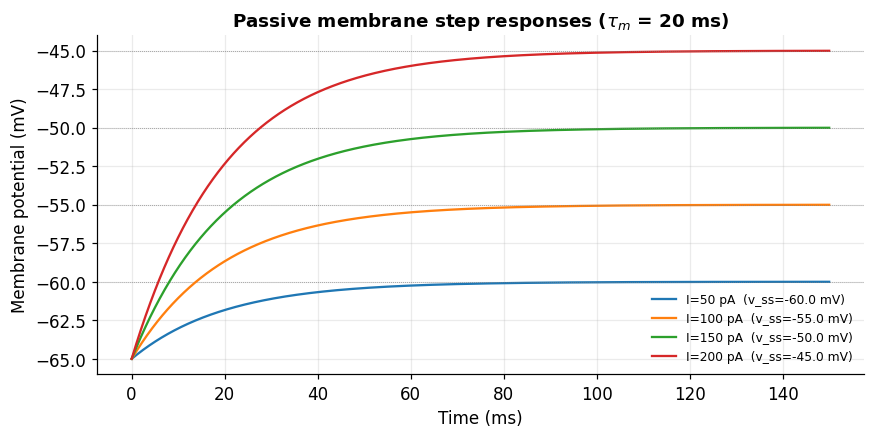

Steady-state deflection scales linearly with I, exactly as R*I predicts:
  I=  50 pA  ->  predicted deflection =   5.0 mV
  I= 100 pA  ->  predicted deflection =  10.0 mV
  I= 150 pA  ->  predicted deflection =  15.0 mV
  I= 200 pA  ->  predicted deflection =  20.0 mV


In [2]:
passive = PassiveNeuron(C_m=200.0, g_L=10.0, v_rest=-65.0, dt=0.1)

currents = [50, 100, 150, 200]
fig, ax = plt.subplots()
for I in currents:
    passive.reset_state()
    res = passive.simulate(I_ext=I, T=150.0)
    v_ss = passive.v_rest + I / passive.g_L
    ax.plot(res["t"], res["v"], label=f"I={I} pA  (v_ss={v_ss:.1f} mV)")
    ax.axhline(v_ss, color="gray", lw=0.5, ls=":")

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Membrane potential (mV)")
ax.set_title(f"Passive membrane step responses ($\\tau_m$ = {passive.tau_m:.0f} ms)")
ax.legend(fontsize=8, loc="lower right")
plt.show()

print("Steady-state deflection scales linearly with I, exactly as R*I predicts:")
for I in currents:
    print(f"  I={I:4d} pA  ->  predicted deflection = {I*passive.R:5.1f} mV")


**Observation.** Every trace relaxes toward its own steady state with the *same* time constant $\tau_m = C_m/g_L$ — only the plateau height changes, and it changes *linearly* with $I$. This is exactly what "passive" means: the membrane has no voltage-dependent conductances, so it behaves as a simple linear filter.

### The point of this baseline: it can never spike

No matter how large the current, there is no mechanism in this model that can produce a spike.

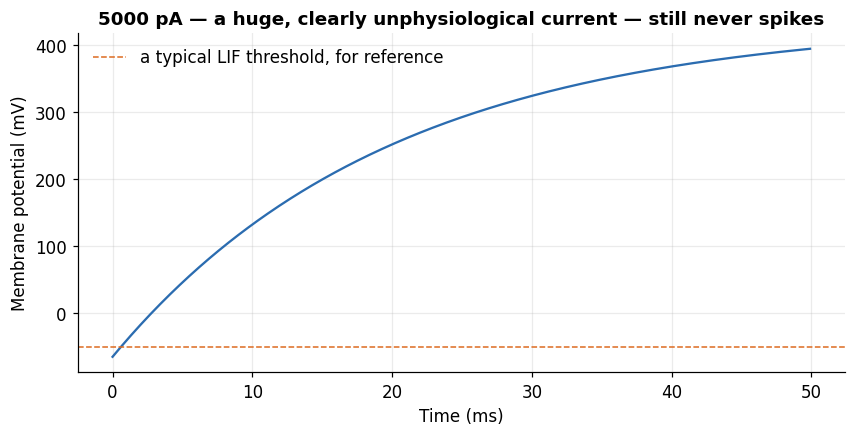

Final voltage: 394 mV. No spike mechanism exists, so none occurs, no matter the input.


In [3]:
passive.reset_state()
res = passive.simulate(I_ext=5000.0, T=50.0)

fig, ax = plt.subplots()
ax.plot(res["t"], res["v"], color=COLOR_V)
ax.axhline(-50, color=COLOR_TH, ls="--", lw=1, label="a typical LIF threshold, for reference")
ax.set_xlabel("Time (ms)"); ax.set_ylabel("Membrane potential (mV)")
ax.set_title("5000 pA — a huge, clearly unphysiological current — still never spikes")
ax.legend()
plt.show()

print(f"Final voltage: {res['v'][-1]:.0f} mV. No spike mechanism exists, so none occurs, no matter the input.")


## 2. Adding a threshold: the Leaky Integrate-and-Fire neuron

The LIF neuron keeps the *exact same* sub-threshold equation, and adds one rule:

$$v(t) \geq v_{th} \;\Longrightarrow\; \text{spike}, \quad v \leftarrow v_{reset}, \quad \text{then hold for } t_{ref}\text{ ms}$$

Below rheobase, a LIF neuron's trace is indistinguishable from the passive membrane's — it's only once the steady state would exceed $v_{th}$ that the two models diverge.

Rheobase (minimum current for sustained firing): 150 pA


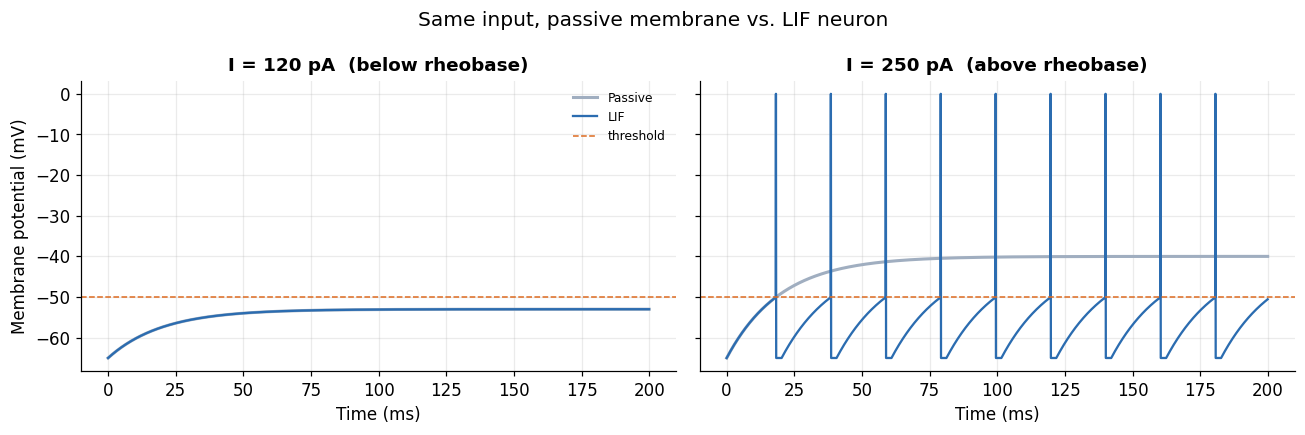

In [4]:
lif = LIFNeuron(C_m=200.0, g_L=10.0, v_rest=-65.0, v_th=-50.0, v_reset=-65.0, t_ref=2.0, dt=0.1)
rheobase = lif.g_L * (lif.v_th - lif.v_rest)
print(f"Rheobase (minimum current for sustained firing): {rheobase:.0f} pA")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, I in zip(axes, [120, 250]):
    passive.reset_state(); lif.reset_state()
    r_p = passive.simulate(I_ext=I, T=200.0)
    r_l = lif.simulate(I_ext=I, T=200.0)
    ax.plot(r_p["t"], r_p["v"], color=COLOR_PASSIVE, lw=2, label="Passive")
    ax.plot(r_l["t"], r_l["v"], color=COLOR_V, label="LIF")
    ax.axhline(lif.v_th, color=COLOR_TH, ls="--", lw=1, label="threshold")
    ax.set_title(f"I = {I} pA  ({'below' if I < rheobase else 'above'} rheobase)")
    ax.set_xlabel("Time (ms)")
axes[0].set_ylabel("Membrane potential (mV)")
axes[0].legend(fontsize=8)
fig.suptitle("Same input, passive membrane vs. LIF neuron")
plt.tight_layout()
plt.show()


Below rheobase (120 pA), the two models are identical — the LIF neuron's voltage approaches its steady state and simply never reaches threshold. Above rheobase (250 pA), the passive membrane plateaus harmlessly, while the LIF neuron fires repeatedly, resetting each time it crosses threshold.

## 3. The F-I curve

The **frequency-current (F-I) curve** — steady-state firing rate as a function of constant input current — is the single most basic characterization of an excitable neuron. `BaseNeuron.f_i_curve` sweeps a range of currents, discards an initial transient, and counts spikes per second.

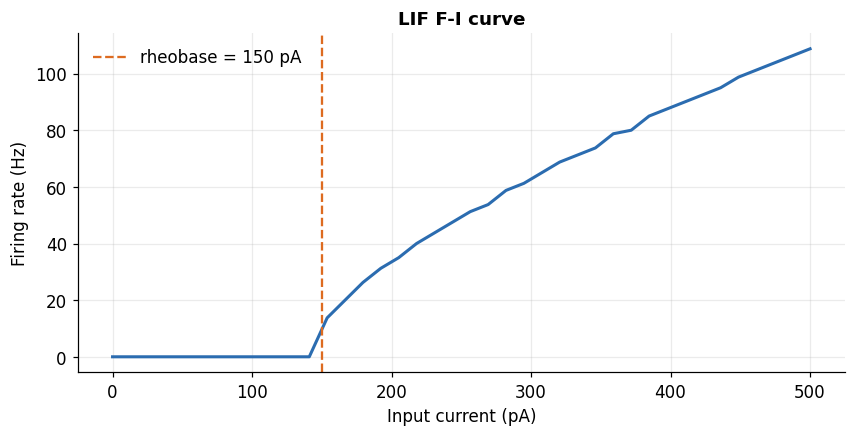

In [5]:
lif = LIFNeuron()
I_values = np.linspace(0, 500, 40)
rates = lif.f_i_curve(I_values, T=1000.0, transient=200.0)

fig, ax = plt.subplots()
ax.plot(I_values, rates, color=COLOR_V, lw=2)
ax.axvline(rheobase, color=COLOR_TH, ls="--", label=f"rheobase = {rheobase:.0f} pA")
ax.set_xlabel("Input current (pA)")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title("LIF F-I curve")
ax.legend()
plt.show()


The curve is exactly zero below rheobase, then rises — steeply at first, then bending over. That bend is the **refractory period** starting to bite: as input grows, the neuron would like to fire faster, but $t_{ref}$ puts a hard ceiling on how many spikes per second are even possible.

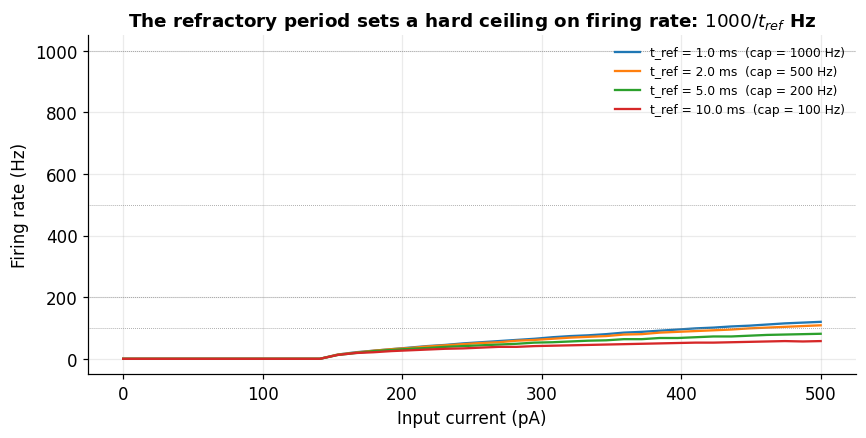

In [6]:
fig, ax = plt.subplots()
for t_ref in [1.0, 2.0, 5.0, 10.0]:
    lif_r = LIFNeuron(t_ref=t_ref)
    rates_r = lif_r.f_i_curve(I_values, T=1000.0, transient=200.0)
    ax.plot(I_values, rates_r, label=f"t_ref = {t_ref} ms  (cap = {1000/t_ref:.0f} Hz)")
    ax.axhline(1000 / t_ref, color="gray", lw=0.5, ls=":")

ax.set_xlabel("Input current (pA)")
ax.set_ylabel("Firing rate (Hz)")
ax.set_title("The refractory period sets a hard ceiling on firing rate: $1000/t_{ref}$ Hz")
ax.legend(fontsize=8)
plt.show()


## 4. Euler vs. RK4: does the integrator matter here?

`BaseNeuron` offers RK4 purely as a single-neuron analytical cross-check (never used for networks — see its docstring for why). For **LIF**, the sub-threshold dynamics are perfectly *linear*, so we'd expect Euler to already do a good job even at fairly coarse time steps. Let's check, against a very fine-grained (dt=0.005ms) Euler run as ground truth.

Reference (dt=0.005ms): 5 spikes


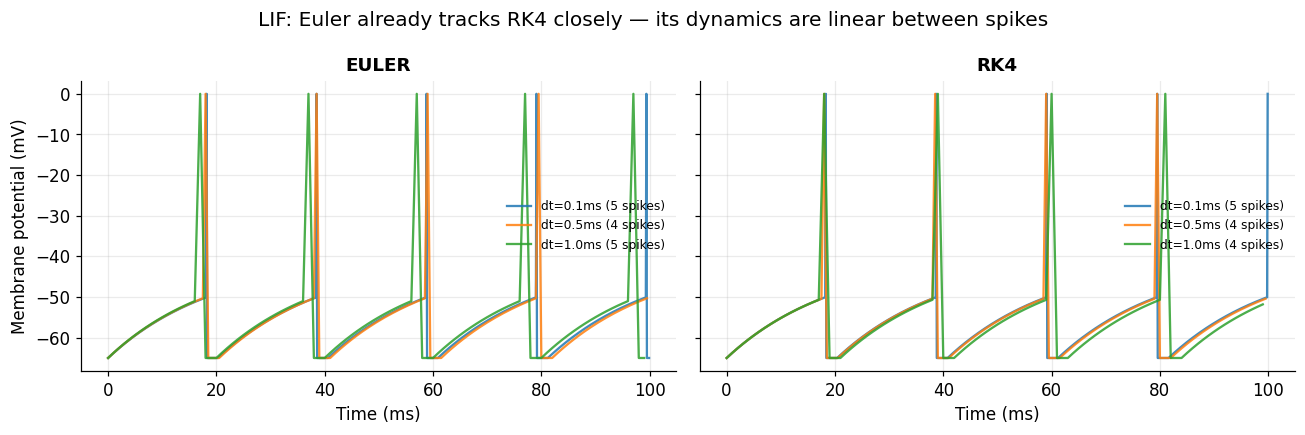

In [7]:
I_test, T_test = 250.0, 100.0
ref = LIFNeuron(dt=0.005)
ref_res = ref.simulate(I_ext=I_test, T=T_test)
print(f"Reference (dt=0.005ms): {len(ref_res['spike_times'])} spikes")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for method, ax in zip(["euler", "rk4"], axes):
    for dt in [0.1, 0.5, 1.0]:
        n = LIFNeuron(dt=dt)
        r = n.simulate(I_ext=I_test, T=T_test, method=method)
        ax.plot(r["t"], r["v"], alpha=0.85, label=f"dt={dt}ms ({len(r['spike_times'])} spikes)")
    ax.set_title(f"{method.upper()}")
    ax.set_xlabel("Time (ms)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("Membrane potential (mV)")
fig.suptitle("LIF: Euler already tracks RK4 closely — its dynamics are linear between spikes")
plt.tight_layout()
plt.show()


**Takeaway.** For a *linear* sub-threshold model like LIF, Euler at dt=0.1ms is already essentially as good as RK4 — both match the fine-grained reference to within a spike or two of grid-timing noise. This is exactly why this project standardizes on Euler at dt <= 0.1ms for every network simulation: it's cheap, and for LIF-type dynamics it isn't leaving meaningful accuracy on the table.

That will *not* remain true once we add a real nonlinearity — Notebook 02 revisits this same comparison for the exponential (nonlinear) integrate-and-fire model, where the gap between Euler and RK4 opens up noticeably as dt grows.

## 5. Realistic input: driving a LIF neuron with a synaptic current

So far we've injected artificial step currents. A real neuron's input is a barrage of synaptic events. Let's generate a Poisson presynaptic spike train, filter it through an alpha-function synapse (`src.synapse_models`), and inject *that* into a LIF neuron.

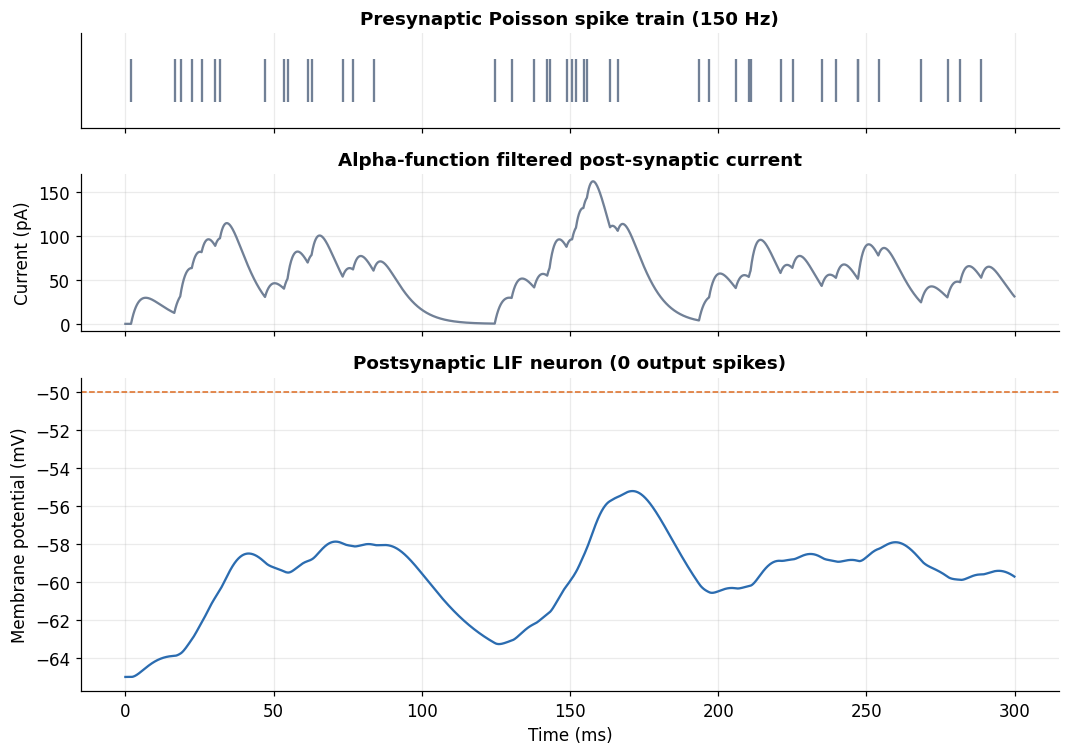

In [8]:
rng = np.random.default_rng(3)
dt = 0.1
poisson = PoissonSpikeGenerator(rate=150.0, dt=dt, n_sources=1, rng=rng)
spike_train = poisson.generate(T=300.0)[:, 0]
I_syn = spikes_to_current(spike_train, tau=5.0, weight=80.0, dt=dt, kind="alpha")

lif_syn = LIFNeuron()
res = lif_syn.simulate(I_ext=I_syn)
t = res["t"]

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True,
                          gridspec_kw={"height_ratios": [0.6, 1, 2]})
axes[0].eventplot(t[spike_train.astype(bool)], colors=COLOR_I, lineoffsets=0.5, linelengths=0.8)
axes[0].set_yticks([]); axes[0].set_title("Presynaptic Poisson spike train (150 Hz)")

axes[1].plot(t, I_syn, color=COLOR_I)
axes[1].set_ylabel("Current (pA)")
axes[1].set_title("Alpha-function filtered post-synaptic current")

axes[2].plot(t, res["v"], color=COLOR_V)
axes[2].axhline(lif_syn.v_th, color=COLOR_TH, ls="--", lw=1)
axes[2].set_ylabel("Membrane potential (mV)"); axes[2].set_xlabel("Time (ms)")
axes[2].set_title(f"Postsynaptic LIF neuron ({len(res['spike_times'])} output spikes)")

plt.tight_layout()
plt.show()


Notice the postsynaptic voltage now fluctuates rather than smoothly charging — every presynaptic spike produces a small EPSP-like bump, and the neuron fires when enough of them happen to land close together. This "fluctuation-driven" spiking, rather than the smooth, clock-like firing we saw under constant current, is the same basic mechanism Notebook 05's 1000-neuron network relies on.

## Summary

- A **passive membrane** is a linear low-pass filter on its input current — with no threshold, it never spikes, at any current.
- The **LIF neuron** adds a hard threshold-and-reset rule on top of the identical sub-threshold equation. Below rheobase it behaves exactly like the passive membrane; above it, it fires repeatedly.
- The **F-I curve** rises from zero at rheobase and saturates as the refractory period caps the maximum possible rate.
- For LIF's *linear* dynamics, Euler at dt=0.1ms already matches RK4 closely — validating the project's Euler-for-networks convention.
- Real (synaptic, fluctuating) input produces qualitatively different, more irregular spiking than a constant current — a preview of Notebook 05.

**Next:** [02 — Non-Linear Integrate-and-Fire](02_Non_Linear_Integrate_and_Fire.ipynb) replaces LIF's hard threshold with a biophysically-motivated exponential nonlinearity, and revisits the Euler-vs-RK4 question for a model where it actually matters.
